In [10]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import(precision_recall_curve, average_precision_score, roc_auc_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

#optional models
try:
    import xgboost as xgb
except Exception as e:
    xgb = None
    print('XGBoost not available: ', e)
try:
    import lightgbm as lgb
except Exception as e:
    lgb = None
    print('LightGBM not available: ', e)

import joblib    

In [11]:
import lightgbm as lgb

In [12]:
# load data
DATA_PATH = 'creditcard.csv'

In [13]:
df = pd.read_csv(DATA_PATH)

In [14]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [15]:
# EDA

In [17]:
df.shape

(284807, 31)

In [18]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [19]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [20]:
 df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [24]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [27]:
fraud_count = df['Class'].value_counts()[1]
total_count = len(df)

fraud_percentage = (fraud_count / total_count)*100
fraud_percentage

np.float64(0.1727485630620034)

In [26]:
fraud_count

np.int64(492)

In [28]:
import seaborn as sns

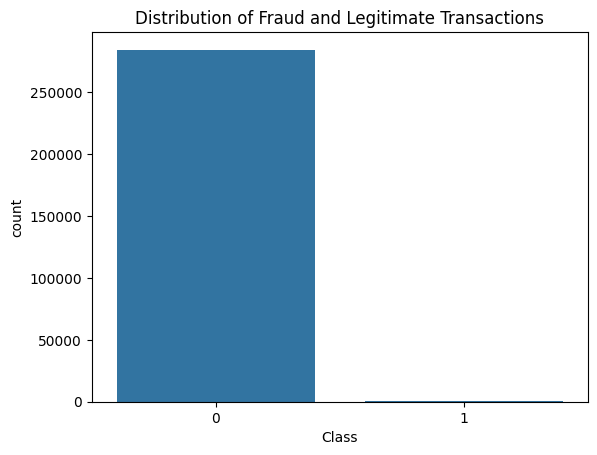

In [29]:
sns.countplot(x = 'Class', data = df)
plt.title('Distribution of Fraud and Legitimate Transactions')
plt.show()

In [30]:
df['Amount'].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

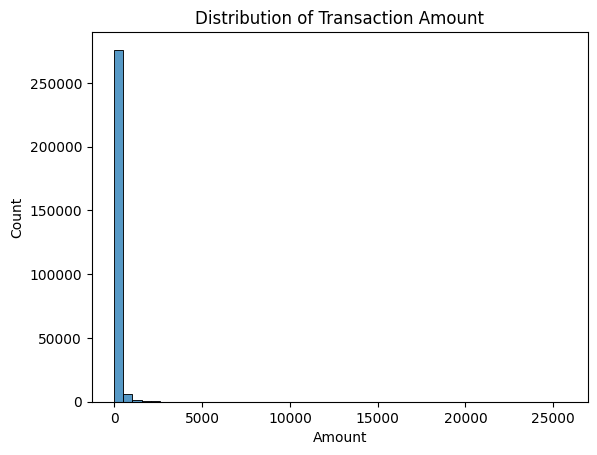

In [32]:
sns.histplot(df['Amount'], bins = 50)
plt.title('Distribution of Transaction Amount')
plt.show()

In [38]:
print("Mean:")
print(df.groupby('Class')['Amount'].mean())

print("\nMedian:")
print(df.groupby('Class')['Amount'].median())

Mean:
Class
0     88.291022
1    122.211321
Name: Amount, dtype: float64

Median:
Class
0    22.00
1     9.25
Name: Amount, dtype: float64


In [39]:
df['Time'].describe()

count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64

In [40]:
df.groupby('Class')['Time'].mean()

Class
0    94838.202258
1    80746.806911
Name: Time, dtype: float64

In [41]:
df.groupby('Class')['Time'].median()

Class
0    84711.0
1    75568.5
Name: Time, dtype: float64

In [42]:
df[['V1', 'V2', 'V3', 'V4', 'V5']].describe() 

,V1,V2,V3,V4,V5
count,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05
mean,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16
std,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00
min,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02
25%,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01
50%,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02
75%,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01
max,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01


In [43]:
df[['V1', 'V2', 'V3', 'V4', 'V5']].head()

,V1,V2,V3,V4,V5
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321
1,1.191857,0.266151,0.166480,0.448154,0.060018
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309
4,-1.158233,0.877737,1.548718,0.403034,-0.407193


In [44]:
df.groupby('Class')['V1'].mean()

Class
0    0.008258
1   -4.771948
Name: V1, dtype: float64

In [45]:
df.groupby('Class')['V1'].median()

Class
0    0.020023
1   -2.342497
Name: V1, dtype: float64

In [46]:
df.groupby('Class')['V2'].mean()

Class
0   -0.006271
1    3.623778
Name: V2, dtype: float64

In [47]:
df.groupby('Class')['V2'].median()

Class
0    0.064070
1    2.717869
Name: V2, dtype: float64

In [48]:
df.corr()['Class'].sort_values()

V17      -0.326481
V14      -0.302544
V12      -0.260593
V10      -0.216883
V16      -0.196539
V3       -0.192961
V7       -0.187257
V18      -0.111485
V1       -0.101347
V9       -0.097733
V5       -0.094974
V6       -0.043643
Time     -0.012323
V24      -0.007221
V13      -0.004570
V15      -0.004223
V23      -0.002685
V22       0.000805
V25       0.003308
V26       0.004455
Amount    0.005632
V28       0.009536
V27       0.017580
V8        0.019875
V20       0.020090
V19       0.034783
V21       0.040413
V2        0.091289
V4        0.133447
V11       0.154876
Class     1.000000
Name: Class, dtype: float64

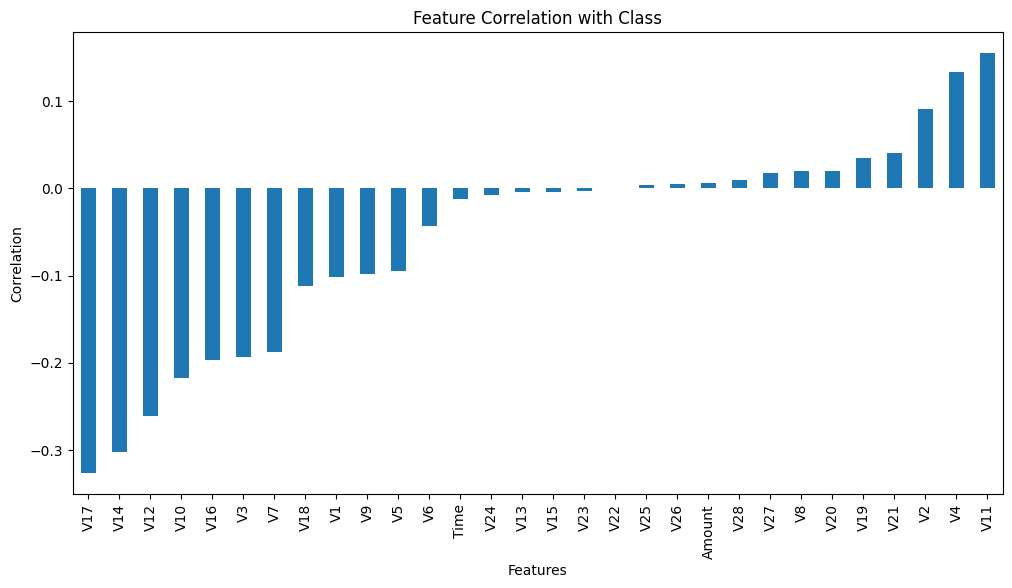

In [49]:
correlation = df.corr()['Class'].drop('Class').sort_values()

correlation.plot(kind='bar', figsize=(12, 6))

plt.title('Feature Correlation with Class')
plt.xlabel('Features')
plt.ylabel('Correlation')
plt.show()

In [50]:
df.duplicated().sum()

np.int64(1081)

In [51]:
df.duplicated().value_counts()


False    283726
True       1081
Name: count, dtype: int64

In [52]:
df[df.duplicated(keep=False)]['Class'].value_counts()

Class
0    1822
1      32
Name: count, dtype: int64

In [53]:
df[df.duplicated(keep=False)].sort_values(by='Class').head(20)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
282210,170731.0,2.033492,0.766969,-2.107555,3.631952,1.348594,-0.499907,0.945159,-0.286392,-1.370581,...,0.241894,0.658545,-0.102644,0.580535,0.643637,0.347240,-0.116618,-0.078601,0.76,0
2732,2270.0,-2.181204,1.505528,0.705044,1.484834,-1.060910,1.094772,-1.146884,1.819827,0.679563,...,-0.370289,-0.813721,-0.070665,-0.794725,0.186404,-0.303576,0.280963,0.074057,13.98,0
2733,2270.0,-2.187707,1.495286,0.709591,1.487350,-1.037785,1.079047,-1.168459,1.824193,0.680840,...,-0.367229,-0.815584,-0.072518,-0.795055,0.185573,-0.304250,0.275004,0.076575,8.79,0
2734,2270.0,-2.187707,1.495286,0.709591,1.487350,-1.037785,1.079047,-1.168459,1.824193,0.680840,...,-0.367229,-0.815584,-0.072518,-0.795055,0.185573,-0.304250,0.275004,0.076575,8.79,0
2735,2270.0,-2.187707,1.495286,0.709591,1.487350,-1.037785,1.079047,-1.168459,1.824193,0.680840,...,-0.367229,-0.815584,-0.072518,-0.795055,0.185573,-0.304250,0.275004,0.076575,8.79,0
2783,2323.0,-2.106211,0.577057,1.717694,1.444458,-0.291290,1.200384,0.382507,-0.271320,1.875879,...,-0.571590,-0.227883,0.050134,0.017689,-0.338141,-0.687573,-1.906314,-0.920435,35.99,0
2784,2323.0,-2.106211,0.577057,1.717694,1.444458,-0.291290,1.200384,0.382507,-0.271320,1.875879,...,-0.571590,-0.227883,0.050134,0.017689,-0.338141,-0.687573,-1.906314,-0.920435,35.99,0
2785,2323.0,-2.126258,0.545482,1.731713,1.452215,-0.219999,1.151908,0.315993,-0.257860,1.879816,...,-0.562156,-0.233625,0.044424,0.016672,-0.340701,-0.689650,-1.924685,-0.912672,19.99,0
2786,2323.0,-2.126258,0.545482,1.731713,1.452215,-0.219999,1.151908,0.315993,-0.257860,1.879816,...,-0.562156,-0.233625,0.044424,0.016672,-0.340701,-0.689650,-1.924685,-0.912672,19.99,0
2997,2550.0,-1.055610,0.012962,2.178270,1.351661,1.462775,-0.167862,1.044716,-0.969907,0.288101,...,-0.219997,0.342678,-0.439939,0.131999,0.027163,-0.341652,-0.949933,-0.500359,13.31,0


In [54]:
df_clean = df.drop_duplicates()

print("Original shape:", df.shape)
print("New shape:", df_clean.shape)

print("\nClass distribution:")
print(df_clean['Class'].value_counts())

Original shape: (284807, 31)
New shape: (283726, 31)

Class distribution:
Class
0    283253
1       473
Name: count, dtype: int64


In [55]:
df = df_clean

In [56]:
X = df.drop('Class', axis=1)
y = df['Class']

In [57]:
print(X.shape)
print(y.shape)

(283726, 30)
(283726,)


In [58]:
print(y.value_counts())
print(y.value_counts(normalize=True) * 100)

Class
0    283253
1       473
Name: count, dtype: int64
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [60]:
X_train.describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
Time,94900.224390,47488.214282,0.000000,172792.000000
V1,0.005027,1.947293,-56.407510,2.454930
V2,-0.005549,1.649617,-72.715728,22.057729
V3,0.002131,1.507270,-33.680984,9.382558
V4,-0.002025,1.416960,-5.683171,16.875344
V5,0.004941,1.359643,-32.092129,34.801666
V6,-0.001961,1.323401,-26.160506,21.393069
V7,0.001480,1.200181,-43.557242,34.303177
V8,-0.000215,1.169342,-73.216718,20.007208
V9,-0.002883,1.094055,-13.434066,15.594995


In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [62]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [63]:
y_pred = lr_model.predict(X_test_scaled)

In [64]:
y_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

In [65]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

[[56641    10]
 [   40    55]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.58      0.69        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.84     56746
weighted avg       1.00      1.00      1.00     56746



In [66]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_test, y_pred_proba)

print("PR-AUC:", pr_auc)

PR-AUC: 0.6919665484964556


In [67]:
lr_balanced = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

lr_balanced.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [68]:
y_pred_balanced = lr_balanced.predict(X_test_scaled)

y_pred_proba_balanced = lr_balanced.predict_proba(X_test_scaled)[:, 1]

print(confusion_matrix(y_test, y_pred_balanced))
print(classification_report(y_test, y_pred_balanced))

pr_auc_balanced = average_precision_score(
    y_test,
    y_pred_proba_balanced
)

print("PR-AUC:", pr_auc_balanced)

[[55262  1389]
 [   12    83]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.87      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746

PR-AUC: 0.6719244530518995


In [69]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [70]:
from imblearn.over_sampling import SMOTE

In [71]:
smote = SMOTE(
    sampling_strategy=0.5,
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [72]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE:
Class
0    226602
1    113301
Name: count, dtype: int64


In [73]:
print("Before:", y_train.value_counts(normalize=True) * 100)
print("After:", y_train_smote.value_counts(normalize=True) * 100)

Before: Class
0    99.833466
1     0.166534
Name: proportion, dtype: float64
After: Class
0    66.666667
1    33.333333
Name: proportion, dtype: float64


In [74]:
lr_smote = LogisticRegression(max_iter=1000)

lr_smote.fit(X_train_smote, y_train_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [75]:
y_pred_smote = lr_smote.predict(X_test_scaled)

y_pred_proba_smote = lr_smote.predict_proba(X_test_scaled)[:, 1]

In [76]:
print(confusion_matrix(y_test, y_pred_smote))
print(classification_report(y_test, y_pred_smote))

pr_auc_smote = average_precision_score(
    y_test,
    y_pred_proba_smote
)

print("PR-AUC:", pr_auc_smote)

[[55961   690]
 [   12    83]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56651
           1       0.11      0.87      0.19        95

    accuracy                           0.99     56746
   macro avg       0.55      0.93      0.59     56746
weighted avg       1.00      0.99      0.99     56746

PR-AUC: 0.6532040129954066


# Random Forest

In [77]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [78]:
y_pred_rf = rf_model.predict(X_test)

y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

In [79]:
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

pr_auc_rf = average_precision_score(
    y_test,
    y_pred_proba_rf
)

print("PR-AUC:", pr_auc_rf)

[[56649     2]
 [   28    67]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.71      0.82        95

    accuracy                           1.00     56746
   macro avg       0.99      0.85      0.91     56746
weighted avg       1.00      1.00      1.00     56746

PR-AUC: 0.7960116616802263


In [80]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance)

V14       0.185744
V10       0.120414
V12       0.100224
V17       0.093938
V4        0.093173
V3        0.059786
V16       0.056195
V11       0.053734
V2        0.035560
V9        0.025835
V7        0.017054
V19       0.015439
V21       0.014797
V18       0.011844
V8        0.011361
V27       0.010898
V1        0.010286
V13       0.008713
V20       0.008622
V5        0.008512
V6        0.007835
Amount    0.007380
V26       0.006779
V15       0.006762
V25       0.005223
V24       0.005152
V22       0.005038
V23       0.005027
V28       0.004896
Time      0.003778
dtype: float64


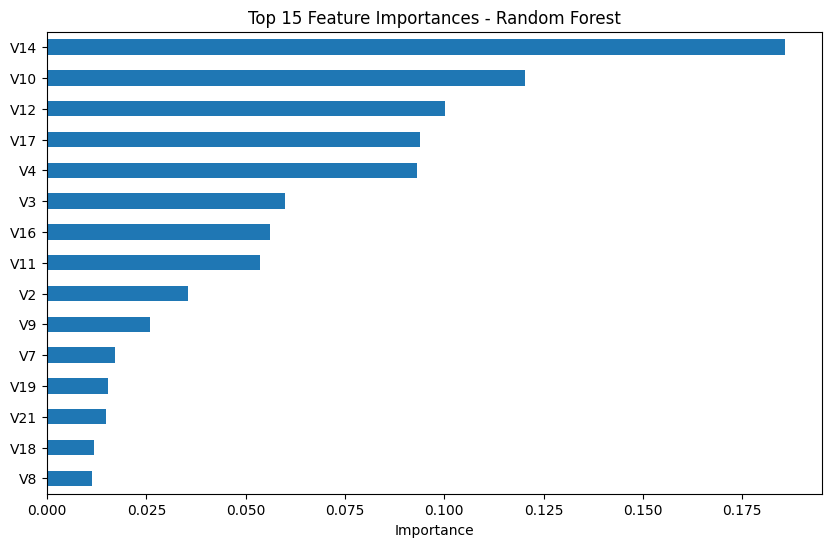

In [81]:
feature_importance.head(15).sort_values().plot(
    kind='barh',
    figsize=(10, 6)
)

plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.show()

In [83]:
import lightgbm

In [84]:
print(lightgbm.__version__)

4.7.0


In [86]:
from lightgbm import LGBMClassifier

In [87]:
lgbm_model = LGBMClassifier(
    n_estimators = 200,
    learning_rate = 0.05,
    num_leaves = 31,
    class_weight = 'balanced',
    random_state = 42,
    n_jobs = -1
)

In [88]:
lgbm_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 378, number of negative: 226602
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.019080 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 226980, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [89]:
y_pred_lgbm = lgbm_model.predict(X_test)

y_pred_proba_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

In [90]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    average_precision_score
)

print(confusion_matrix(y_test, y_pred_lgbm))

print(classification_report(
    y_test,
    y_pred_lgbm
))

pr_auc_lgbm = average_precision_score(
    y_test,
    y_pred_proba_lgbm
)

print("PR-AUC:", pr_auc_lgbm)

[[56636    15]
 [   21    74]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.83      0.78      0.80        95

    accuracy                           1.00     56746
   macro avg       0.92      0.89      0.90     56746
weighted avg       1.00      1.00      1.00     56746

PR-AUC: 0.808606853766622


In [91]:
lgbm_importance = pd.Series(
    lgbm_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(lgbm_importance)

V14       440
V4        389
V12       314
V10       267
V8        238
V24       236
V22       234
V11       231
V26       225
V27       215
V3        211
V5        206
V18       200
V7        200
V17       198
V19       192
V13       177
Amount    168
V2        164
V15       153
V1        151
V28       147
V16       144
V6        140
V9        137
Time      134
V20       129
V25       124
V23       119
V21       117
dtype: int32


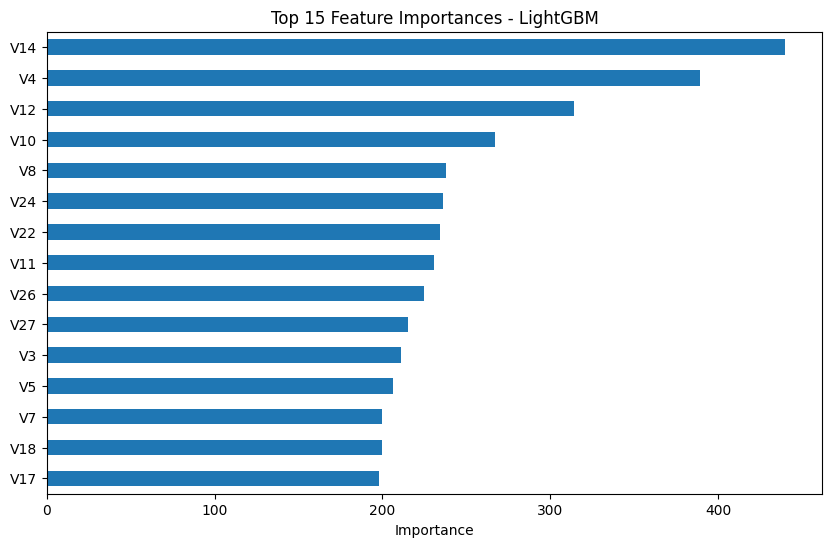

In [94]:
lgbm_importance.head(15).sort_values().plot(
    kind='barh',
    figsize=(10, 6)
)

plt.title("Top 15 Feature Importances - LightGBM")
plt.xlabel("Importance")
plt.show()

In [95]:
lgbm = LGBMClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

In [96]:
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'num_leaves': [15, 31, 50, 70],
    'max_depth': [-1, 5, 10, 15],
    'min_child_samples': [10, 20, 30, 50],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

In [97]:
random_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_grid,
    n_iter=20,
    scoring='average_precision',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [98]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,estimator,LGBMClassifie... verbosity=-1)
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [-1, 5, ...], 'min_child_samples': [10, 20, ...], ...}"
,n_iter,20
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [99]:
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'subsample': 0.8, 'num_leaves': 50, 'n_estimators': 500, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


In [100]:
print("Best CV PR-AUC:")
print(random_search.best_score_)

Best CV PR-AUC:
0.8530638898836734


In [101]:
best_lgbm = random_search.best_estimator_

In [102]:
y_pred_tuned = best_lgbm.predict(X_test)

y_pred_proba_tuned = best_lgbm.predict_proba(X_test)[:, 1]

In [103]:
print(confusion_matrix(y_test, y_pred_tuned))

print(classification_report(
    y_test,
    y_pred_tuned
))

pr_auc_tuned = average_precision_score(
    y_test,
    y_pred_proba_tuned
)

print("Test PR-AUC:", pr_auc_tuned)

[[56648     3]
 [   23    72]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.96      0.76      0.85        95

    accuracy                           1.00     56746
   macro avg       0.98      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746

Test PR-AUC: 0.8295957813491255
